In [ ]:
import sklearn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split

In [ ]:
dataset = pd.read_csv("Iris.csv")
factorization_table = {}

if 'Id' in dataset.columns:
    dataset.drop(['Id'], axis=1, inplace=True)

COLUMNS_FOR_FACTORISATION = ["Species"]
for column in dataset.columns:
    if column in COLUMNS_FOR_FACTORISATION:
        dataset[column], table = pd.factorize(dataset[column])
        factorization_table[column] = pd.DataFrame(
            columns=[column],
            data=table
        )

Проверка на значимость признаков и их корреляцию

Построение модели

In [ ]:
train_input, test_input, train_output, test_output = train_test_split(
    dataset.drop("Species", axis=1),
    dataset["Species"],
    test_size=0.2
)

Матрица сходства предсказанных значений тестового набора и эталонных значений

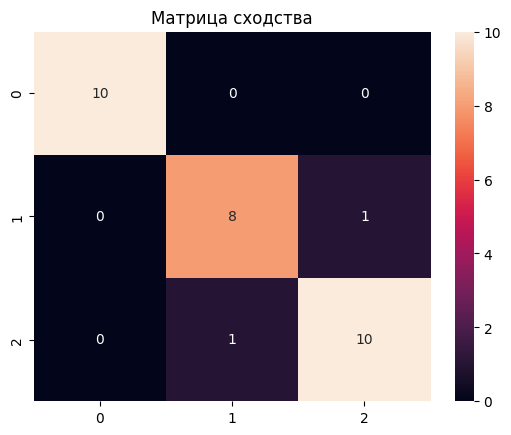

In [ ]:
model = tree.DecisionTreeClassifier(criterion="entropy", max_depth=6)
model.fit(train_input, train_output)
predictions = model.predict(test_input)
confusion_matrix = sklearn.metrics.confusion_matrix(predictions, test_output)
sns.heatmap(
    confusion_matrix,
    annot=True
)
plt.title('Матрица сходства')
plt.show()

Получение дерева решений

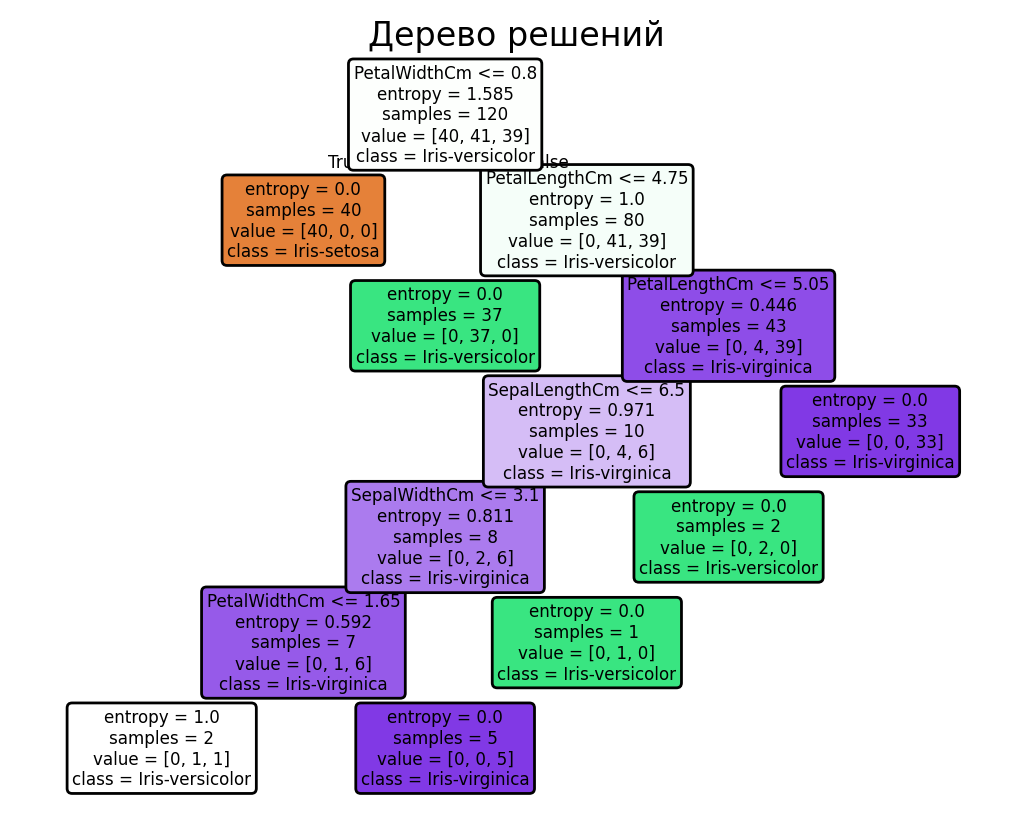

In [ ]:
DPI = 200
plt.figure(dpi=DPI)
tree.plot_tree(
    model,
    feature_names=dataset.columns[:-1],
    class_names=factorization_table["Species"].values.flatten(),
    filled=True,
    rounded=True
)
plt.title("Дерево решений")
plt.show()